# Working with single data/variable (Univariate Analysis)

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", context="talk", palette="muted")

In [70]:
data = pd.read_csv("train.csv")

In [71]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [72]:
data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
109,110,1,3,"Moran, Miss. Bertha",female,NaN,1,0,371110,24.1500,NaN,Q
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12.0,1,0,2651,11.2417,NaN,C
48,49,0,3,"Samaan, Mr. Youssef",male,NaN,2,0,2662,21.6792,NaN,C
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C


## 1. Working with Qualitative/Categorical Data


### a. Frequency Distibution Table

In [73]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [74]:
data["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


### b. Bar chart

<Axes: xlabel='Pclass'>

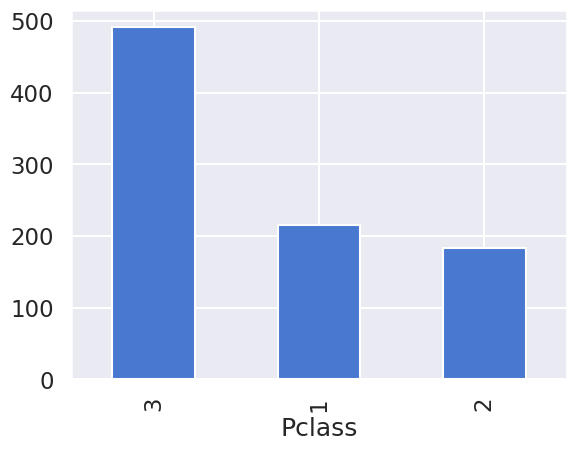

In [75]:
data["Pclass"].value_counts().plot(kind="bar")

### c. Pie Chart

<Axes: ylabel='count'>

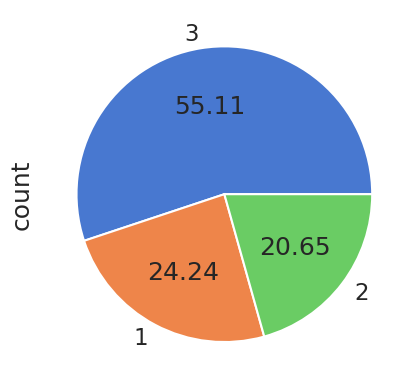

In [76]:
data["Pclass"].value_counts().plot(kind="pie", autopct="%.2f")

### d. Cumulative Frequency

The frequency is the number of times an event occurs within a given scenario. Cumulative frequency is defined as the running total of frequencies. It is the sum of all the previous frequencies up to the current point. It is easily understandable through a Cumulative Frequency Table.

In [77]:
a = data["Pclass"].value_counts()

In [78]:
a

,count
Pclass,
3,491
1,216
2,184


In [79]:
b = ((a/a.sum())*100).values

In [80]:
b

array([55.10662177, 24.24242424, 20.65095398])

In [81]:
c = []
cf = 0
for i in b:
  cf = cf + i
  c.append(cf)

In [82]:
c

[np.float64(55.106621773288445),
 np.float64(79.34904601571269),
 np.float64(100.0)]

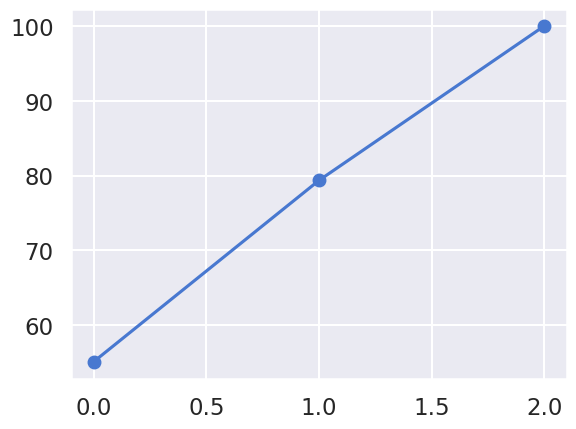

In [83]:
plt.plot(c, marker="o")

## 2. Working with Quantative/Numerical Data

### a. Histogram

In [84]:
data["Age"].value_counts() # we might get counts in term of categories but still large number of categories

,count
Age,
24.00,30
22.00,27
18.00,26
28.00,25
30.00,25
...,...
24.50,1
0.67,1
0.42,1


(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

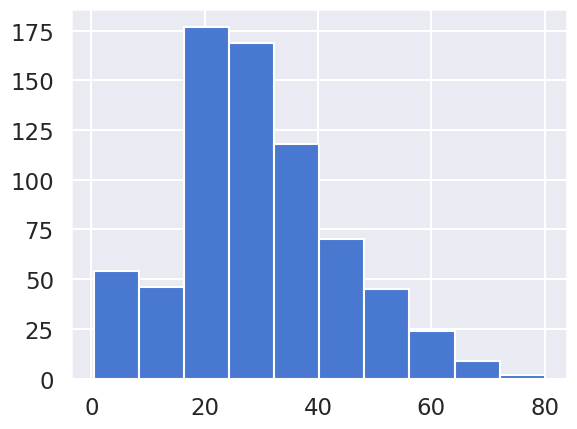

In [85]:
# solution is to make buckets of ages and add frequency per bucket
plt.hist(data["Age"], bins=10)

### b. Box Plot

<Axes: ylabel='Age'>

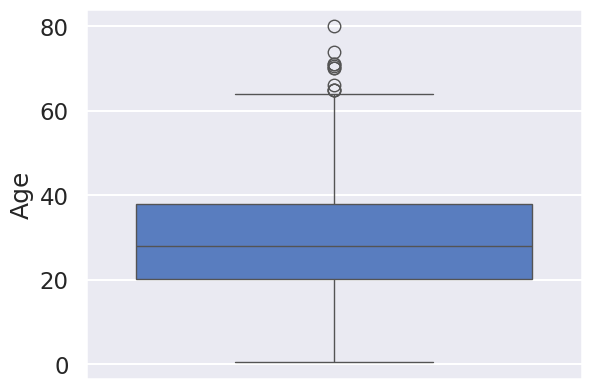

In [86]:
sns.boxplot(data["Age"])

In [87]:
a = data.dropna(subset = ["Age"])
a = a["Age"]
np.median(a)

np.float64(28.0)

### c. KDE plot

<Axes: xlabel='Age', ylabel='Density'>

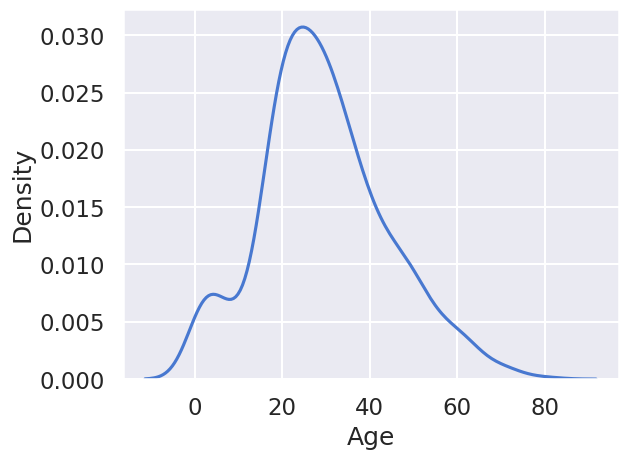

In [88]:
sns.kdeplot(data["Age"])

# Working with 2 variables/data (Bivariate Analysis)

## 1. Categorical VS Numerical

### a. Box Plot

<Axes: xlabel='Pclass', ylabel='Age'>

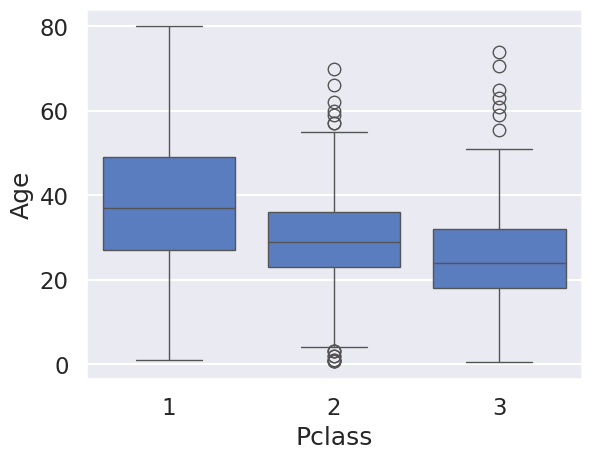

In [89]:
# Pclass -> categorical, Age -> Numerical
sns.boxplot(x = "Pclass", y = "Age", data = data)

### b. Bar Plot

<Axes: xlabel='Pclass', ylabel='Age'>

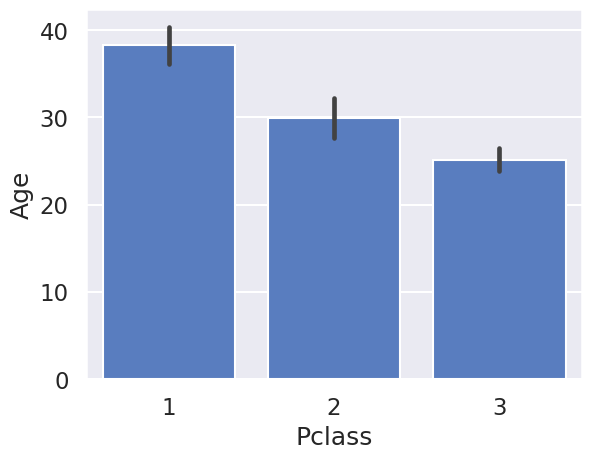

In [90]:
sns.barplot(x = "Pclass", y = "Age", data = data) # it tells the average

## 2. Numerical VS Numerical

### a. Scatter Plot

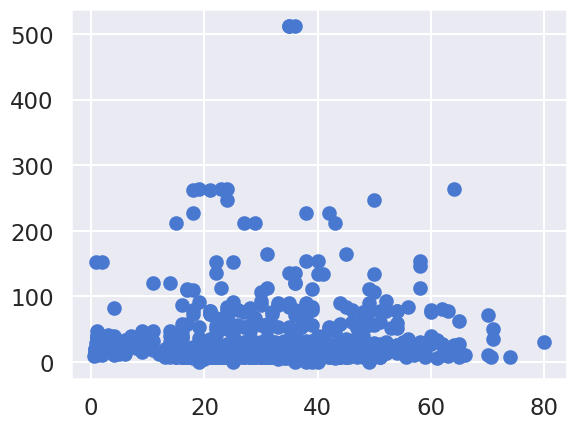

In [95]:
# If you want to find the relation between two numeric columns
n = data["Age"].values
m = data["Fare"].values
plt.scatter(n, m) # No relation

## 3. Categorical VS Categorical

### a. Cross Table/ Contingency Table

A cross table (or contingency table) is a matrix that displays the frequency distribution of two or more categorical variables simultaneously. It helps you easily analyze relationships, patterns, and dependencies between data groups by showing how often different categories intersect.

In [96]:
pd.crosstab(data["Pclass"], data["Sex"])

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


### b. Side by side Chart

<Axes: xlabel='Pclass'>

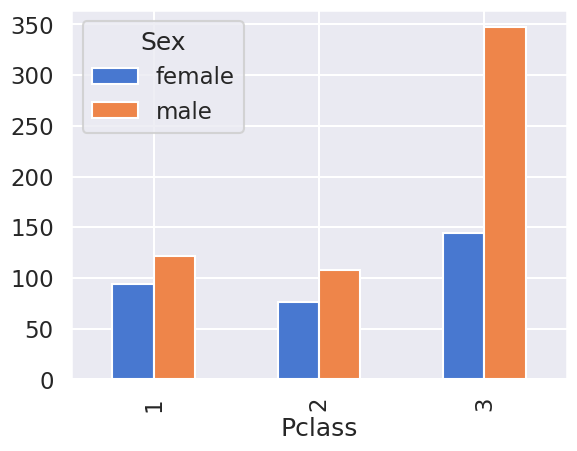

In [101]:
pd.crosstab(data["Pclass"], data["Sex"]).plot(kind = "bar")

### c. Heat Map

<Axes: xlabel='Sex', ylabel='Pclass'>

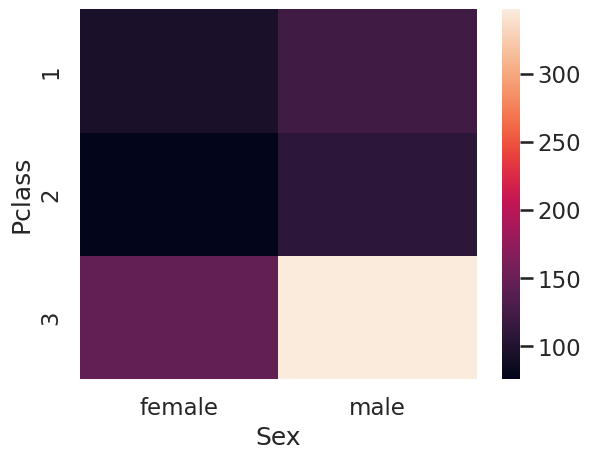

In [102]:
ct = pd.crosstab(data["Pclass"], data["Sex"])
sns.heatmap(ct)